In [2]:
import pandas as pd

In [3]:
df = pd.read_excel(r"C:\Users\Super-A\Desktop\Project_3_Ecommerce_Revenue_Analytics\data\online_retail.xlsx")

In [4]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df.shape

(406829, 8)

In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df.shape

(397924, 8)

In [12]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

In [15]:
df[['InvoiceDate','OrderMonth']].head()

,InvoiceDate,OrderMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [16]:
df['OrderYear'] = df['InvoiceDate'].dt.year

In [17]:
df[['InvoiceDate','OrderYear']].head()

,InvoiceDate,OrderYear
0,2010-12-01 08:26:00,2010
1,2010-12-01 08:26:00,2010
2,2010-12-01 08:26:00,2010
3,2010-12-01 08:26:00,2010
4,2010-12-01 08:26:00,2010


In [18]:
df['CustomerPurchaseCount'] = df.groupby('CustomerID')['InvoiceNo'].transform('nunique')

In [19]:
df[['CustomerID','InvoiceNo','CustomerPurchaseCount']].head()

,CustomerID,InvoiceNo,CustomerPurchaseCount
0,17850.0,536365,34
1,17850.0,536365,34
2,17850.0,536365,34
3,17850.0,536365,34
4,17850.0,536365,34


In [20]:
df['CustomerLifetimeValue'] = df.groupby('CustomerID')['Revenue'].transform('sum')

In [21]:
df[['CustomerID','Revenue','CustomerLifetimeValue']].head()

,CustomerID,Revenue,CustomerLifetimeValue
0,17850.0,15.30,5391.21
1,17850.0,20.34,5391.21
2,17850.0,22.00,5391.21
3,17850.0,20.34,5391.21
4,17850.0,20.34,5391.21


In [22]:
df.sort_values(by='Revenue', ascending=False).head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,OrderMonth,OrderYear,CustomerPurchaseCount,CustomerLifetimeValue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60,2011-12,2011,2,168472.50
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60,2011-01,2011,1,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00,2011-06,2011,3,39916.50
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75,2011-05,2011,63,81024.84
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72,2011-09,2011,46,194550.79


In [23]:
monthly_revenue = df.groupby('OrderMonth')['Revenue'].sum().reset_index()

In [24]:
monthly_revenue.head()

,OrderMonth,Revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361


<Axes: xlabel='OrderMonth'>

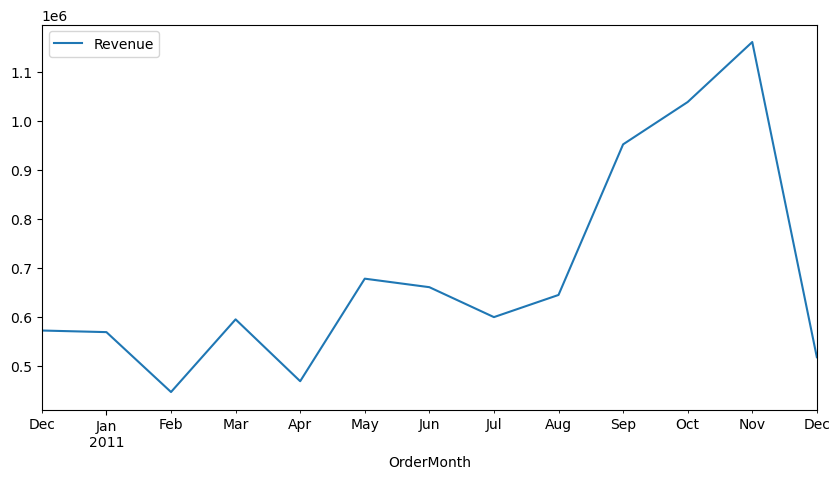

In [25]:
monthly_revenue.plot(x='OrderMonth', y='Revenue', kind='line', figsize=(10,5))

In [26]:
import matplotlib.pyplot as plt

In [27]:
plt.show()

In [28]:
country_revenue = df.groupby('Country')['Revenue'].sum().reset_index()

In [29]:
country_revenue.sort_values(by='Revenue', ascending=False).head(10)

,Country,Revenue
35,United Kingdom,7308391.554
23,Netherlands,285446.340
10,EIRE,265545.900
14,Germany,228867.140
13,France,209024.050
0,Australia,138521.310
30,Spain,61577.110
32,Switzerland,56443.950
3,Belgium,41196.340
31,Sweden,38378.330


In [30]:
top_countries = country_revenue.sort_values(by='Revenue', ascending=False).head(10)

<Axes: xlabel='Country'>

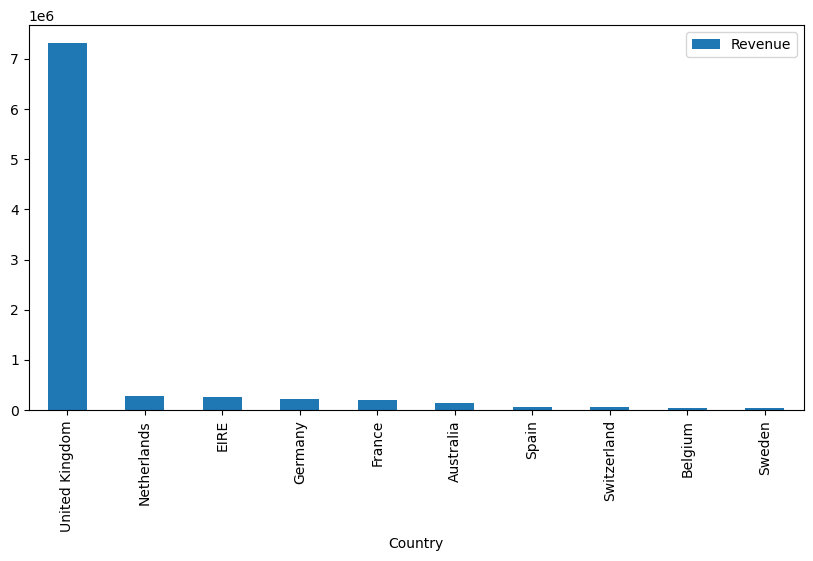

In [31]:
top_countries.plot(x='Country', y='Revenue', kind='bar', figsize=(10,5))

In [32]:
product_revenue = df.groupby('Description')['Revenue'].sum().reset_index()


In [33]:
product_revenue.sort_values(by='Revenue', ascending=False).head(10)

,Description,Revenue
2319,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2767,REGENCY CAKESTAND 3 TIER,142592.95
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
1762,JUMBO BAG RED RETROSPOT,85220.78
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
2611,POSTAGE,77803.96
2345,PARTY BUNTING,68844.33
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34
2130,Manual,53779.93
2656,RABBIT NIGHT LIGHT,51346.20


In [34]:
top_products = product_revenue.sort_values(by='Revenue', ascending=False).head(10)

<Axes: xlabel='Description'>

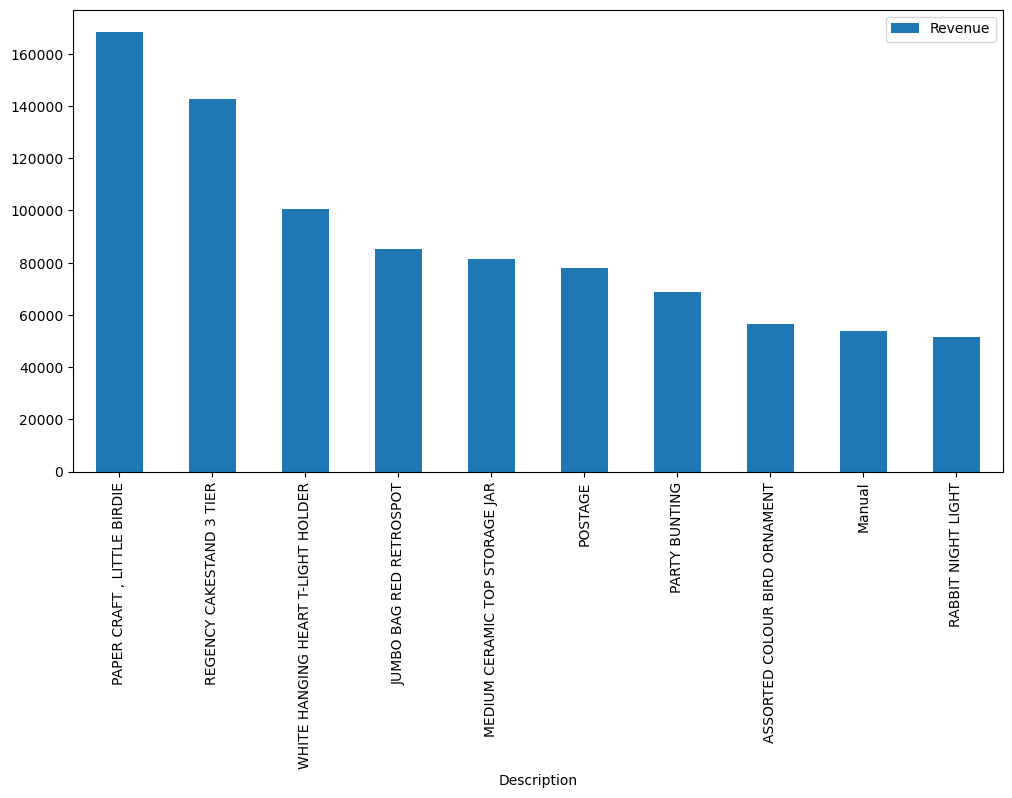

In [35]:
top_products.plot(x='Description', y='Revenue', kind='bar', figsize=(12,6))

In [36]:
repeat_customers = df[df['CustomerPurchaseCount'] > 1]['CustomerID'].nunique()

In [37]:
one_time_customers = df[df['CustomerPurchaseCount'] == 1]['CustomerID'].nunique()

In [38]:
repeat_customers, one_time_customers

(2845, 1494)

In [39]:
customer_summary = df.groupby('CustomerID').agg({
    'Revenue':'sum',
    'InvoiceNo':'nunique',
    'Quantity':'sum'
}).reset_index()

In [40]:
customer_summary.head()

,CustomerID,Revenue,InvoiceNo,Quantity
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


In [41]:
customer_summary.sort_values(by='Revenue', ascending=False).head(10)

,CustomerID,Revenue,InvoiceNo,Quantity
1690,14646.0,280206.02,74,197491
4202,18102.0,259657.30,60,64124
3729,17450.0,194550.79,46,69993
3009,16446.0,168472.50,2,80997
1880,14911.0,143825.06,201,80515
55,12415.0,124914.53,21,77670
1334,14156.0,117379.63,55,57885
3772,17511.0,91062.38,31,64549
2703,16029.0,81024.84,63,40208
0,12346.0,77183.60,1,74215


In [42]:
average_order_value = df['Revenue'].sum() / df['InvoiceNo'].nunique()

In [43]:
average_order_value

np.float64(480.7621873111782)

In [45]:
df['InvoiceDate'] = df['InvoiceDate'].astype(str)

In [46]:
df.to_csv(r"C:\Users\Super-A\Desktop\Project_3_Ecommerce_Revenue_Analytics\data\cleaned_ecommerce_data.csv", index=False)